# Эксперимент 3.3 — сходимость по $F(x)-F^*$

$F^*$ оценивается **FISTA на 10\,000 итераций**. Параметры $\lambda$ и $R$ согласованы ($R \approx \|x^*\|_1$ по решению FISTA).  
Графики: $\log(F(x_k)-F^*)$ от **кумулятивного числа вызовов оракула** и от **времени** (барьер: суммарные вызовы `func/grad/hess` на размерности $2n$ внутри Ньютона — поле `aug_oracle_calls`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents][:12]:
        if (p / "src" / "optimization.py").is_file():
            return p
    return here


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT))

from src.counted_oracle import CountedCompositeOracle, CountedNonsmoothOracle, CountedSmoothOracle
from src.experiment_utils import (
    radius_from_reference,
    synthetic_classification,
    synthetic_regression,
    tune_lambda_for_zero_fraction,
)
from src.oracles import ClassificationNonsmoothOracle, ClassificationProxOracle, RegressionNonsmoothOracle, RegressionProxOracle
from src.optimization import (
    barrier_method,
    frank_wolfe_method,
    proximal_fast_gradient_method,
    subgradient_method,
)
from src.paths import figs_dir

FIG = figs_dir()
rng = np.random.default_rng(11)


def log_gap(Fs, Fstar, floor=1e-14):
    g = np.maximum(np.asarray(Fs, dtype=float) - float(Fstar), floor)
    return np.log10(g)


def oracle_axis(h, barrier):
    if barrier:
        return np.asarray(h["aug_oracle_calls"], dtype=float)
    return np.asarray(h["oracle_calls"], dtype=float)

[регрессия] λ=0.00889 R=0.8268 F*=0.076601


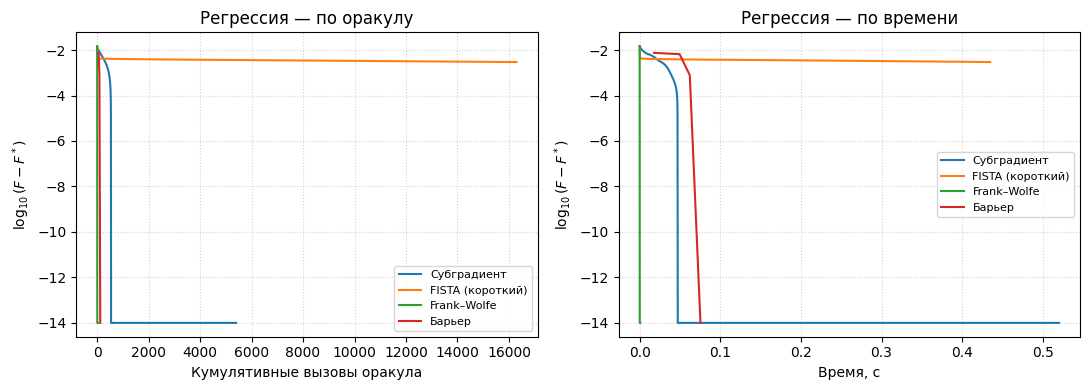

Сохранено C:\Users\axmed\OneDrive\Рабочий стол\proj\NothingElseMatters\figs\exp33_convergence_regression.png
[классификация] λ=0.00889 R=0.0079 F*=0.693032


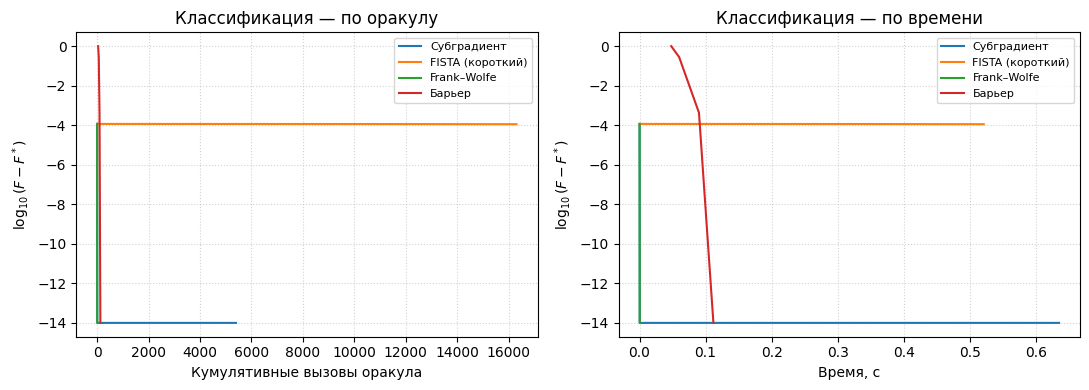

Сохранено C:\Users\axmed\OneDrive\Рабочий стол\proj\NothingElseMatters\figs\exp33_convergence_classification.png


In [2]:
def experiment_task(name, A, b_or_y, build_prox, build_nonsmooth, build_smooth_from_prox, is_classif: bool, max_iter=1800):
    n = A.shape[1]
    x0 = np.zeros(n)

    def build(lam):
        return build_prox(lam)

    lam, _ = tune_lambda_for_zero_fraction(build, n, x0, max_iter_fista=2800)
    comp0 = build_prox(lam)
    x_star, _, _ = proximal_fast_gradient_method(
        CountedCompositeOracle(build_prox(lam)),
        x0,
        L_0=1.0,
        max_iter=10_000,
        tolerance=1e-11,
        trace=False,
    )
    F_star = float(comp0.func(x_star))
    R = radius_from_reference(x_star, scale=1.03)
    print(f"[{name}] λ={lam:.5f} R={R:.4f} F*={F_star:.6f}")

    comp = CountedCompositeOracle(build_prox(lam))
    nons = CountedNonsmoothOracle(build_nonsmooth(lam))
    sm = CountedSmoothOracle(build_prox(lam).smooth)

    hist = {}
    _, _, hist["subgrad"] = subgradient_method(nons, x0, max_iter=max_iter, alpha_0=0.35, trace=True)
    _, _, hist["fista"] = proximal_fast_gradient_method(comp, x0, max_iter=max_iter, tolerance=1e-14, trace=True)
    _, _, hist["fw"] = frank_wolfe_method(
        sm, x0, R, max_iter=max_iter, step_size_strategy="armijo", trace=True, lambda_l1=lam
    )
    u0 = np.abs(x0) + 1.0
    _, _, hist["barrier"] = barrier_method(
        sm,
        x0,
        u0,
        lam,
        t_0=1.0,
        mu=10.0,
        max_iter=40,
        max_inner_iter=100,
        tolerance_inner=1e-4,
        tolerance_outer=0.2,
        trace=True,
    )
    return lam, F_star, hist


def plot_pair(F_star, hist, title, fname_suffix):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    styles = [
        ("subgrad", "Субградиент", False),
        ("fista", "FISTA (короткий)", False),
        ("fw", "Frank–Wolfe", False),
        ("barrier", "Барьер", True),
    ]
    for key, lab, bar in styles:
        h = hist[key]
        y = log_gap(h["F"], F_star)
        xo = oracle_axis(h, bar)
        ax[0].plot(xo, y, label=lab)
        tt = np.asarray(h["time"], dtype=float)
        ax[1].plot(tt, y, label=lab)
    ax[0].set_xlabel("Кумулятивные вызовы оракула")
    ax[0].set_ylabel(r"$\log_{10}(F-F^*)$")
    ax[0].set_title(title + " — по оракулу")
    ax[0].legend(fontsize=8)
    ax[0].grid(True, ls=":", alpha=0.55)
    ax[1].set_xlabel("Время, с")
    ax[1].set_ylabel(r"$\log_{10}(F-F^*)$")
    ax[1].set_title(title + " — по времени")
    ax[1].legend(fontsize=8)
    ax[1].grid(True, ls=":", alpha=0.55)
    plt.tight_layout()
    p = FIG / fname_suffix
    plt.savefig(p, dpi=160, bbox_inches="tight")
    plt.show()
    print("Сохранено", p)


m, n = 100, 36
A_r, b_r, _ = synthetic_regression(m, n, rng)
lam_r, Fsr, h_r = experiment_task(
    "регрессия",
    A_r,
    b_r,
    lambda lam: RegressionProxOracle(A_r, b_r, lam, 0.0),
    lambda lam: RegressionNonsmoothOracle(A_r, b_r, lam, 0.0),
    None,
    False,
)
plot_pair(Fsr, h_r, "Регрессия", "exp33_convergence_regression.png")

A_c, y_c, _ = synthetic_classification(m, n, rng)
lam_c, Fsc, h_c = experiment_task(
    "классификация",
    A_c,
    y_c,
    lambda lam: ClassificationProxOracle(A_c, y_c, lam, 0.0),
    lambda lam: ClassificationNonsmoothOracle(A_c, y_c, lam, 0.0),
    None,
    True,
)
plot_pair(Fsc, h_c, "Классификация", "exp33_convergence_classification.png")

**Интерпретация.** Обычно **FISTA** выигрывает по числу градиентных вызовов; **Frank–Wolfe** дешёв по итерации (один LMO), но линейный поиск может добавлять вызовы `func`. **Барьер** тратит дорогие `hess` на размерности $2n$ — часто медленнее по wall-clock при сопоставимой точности.